In [ ]:
!pip install kaggle --quiet

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import tensorflow as tf
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import (
    Conv2D, DepthwiseConv2D, BatchNormalization,
    MaxPooling2D, GlobalAveragePooling2D, Dropout, Dense
)
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import os

KAGGLE_USERNAME = "meliskmb"
KAGGLE_KEY      = "KGAT_bd360be8d12aa7908ff179fea1de5297"

# Set credentials
os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
with open(os.path.expanduser("~/.kaggle/kaggle.json"), "w") as f:
    f.write(f'{{"username":"{KAGGLE_USERNAME}","key":"{KAGGLE_KEY}"}}')
os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)

# Download dataset
!kaggle datasets download -d emmarex/plantdisease --quiet
!unzip -q plantdisease.zip -d plantvillage
print("Dataset ready!")

Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
replace plantvillage/PlantVillage/Pepper__bell___Bacterial_spot/0022d6b7-d47c-4ee2-ae9a-392a53f48647___JR_B.Spot 8964.JPG? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace plantvillage/PlantVillage/Pepper__bell___Bacterial_spot/006adb74-934f-448f-a14f-62181742127b___JR_B.Spot 3395.JPG? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace plantvillage/PlantVillage/Pepper__bell___Bacterial_spot/00f2e69a-1e56-412d-8a79-fdce794a17e4___JR_B.Spot 3132.JPG? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace plantvillage/PlantVillage/Pepper__bell___Bacterial_spot/01613cd0-d3cd-4e96-945c-a312002037bf___JR_B.Spot 3262.JPG? [y]es, [n]o, [A]ll, [N]one, [r]ename: A

A
Dataset ready!


In [ ]:
# PlantVillage dataset
!kaggle datasets download -d emmarex/plantdisease --quiet
!unzip -q plantdisease.zip -d plantvillage
print("Dataset ready!")

DATA_DIR = None
for root, dirs, files_list in os.walk('plantvillage'):
    if len(dirs) > 10:
        DATA_DIR = root
        break

print(f"Data directory: {DATA_DIR}")
classes = sorted(os.listdir(DATA_DIR))
print(f"Number of classes: {len(classes)}")
print(f"Sample classes: {classes[:5]}")

Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
replace plantvillage/PlantVillage/Pepper__bell___Bacterial_spot/0022d6b7-d47c-4ee2-ae9a-392a53f48647___JR_B.Spot 8964.JPG? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
Dataset ready!
Data directory: plantvillage/plantvillage/PlantVillage
Number of classes: 15
Sample classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']


In [ ]:
# Hyperparameters
IMG_SIZE    = 128      # input image resolution
BATCH_SIZE  = 32
EPOCHS      = 30
LR          = 1e-3
VAL_SPLIT   = 0.15
TEST_SPLIT  = 0.15
SEED        = 42
NUM_CLASSES = len(classes)

print(f"Image size : {IMG_SIZE}x{IMG_SIZE}")
print(f"Batch size : {BATCH_SIZE}")
print(f"Num classes: {NUM_CLASSES}")

Image size : 128x128
Batch size : 32
Num classes: 15


In [ ]:
# Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=VAL_SPLIT + TEST_SPLIT,
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=30,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

# Validation/Test
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=VAL_SPLIT + TEST_SPLIT
)

# Training generator
train_gen = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED
)

# Validation generator
val_gen = val_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED,
    shuffle=False
)

# Class index mapping
class_names = list(train_gen.class_indices.keys())
print(f"Training samples  : {train_gen.samples}")
print(f"Validation samples: {val_gen.samples}")

Found 14452 images belonging to 15 classes.
Found 6186 images belonging to 15 classes.
Training samples  : 14452
Validation samples: 6186


In [ ]:
def depthwise_sep_block(x, filters, strides=1):
    # Step 1: filter each channel independently
    x = DepthwiseConv2D(
        kernel_size=3,
        strides=strides,
        padding='same',
        use_bias=False
    )(x)
    x = BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)

    # Step 2: mix across channels
    x = Conv2D(
        filters=filters,
        kernel_size=1,
        padding='same',
        use_bias=False
    )(x)
    x = BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)

    return x


def build_model(num_classes, img_size=128):
    """
    Architecture:
      Stem Conv → DS Block x4 (with pooling) → GAP → Dropout → Softmax
    """
    inputs = Input(shape=(img_size, img_size, 3))

    # Standard Conv
    x = Conv2D(32, kernel_size=3, strides=2, padding='same', use_bias=False)(inputs)
    x = BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    # Output: 64x64x32

    # Stage 1
    x = depthwise_sep_block(x, filters=64)
    x = MaxPooling2D(pool_size=2)(x)
    # Output: 32x32x64

    # Stage 2
    x = depthwise_sep_block(x, filters=128)
    x = depthwise_sep_block(x, filters=128)
    x = MaxPooling2D(pool_size=2)(x)
    # Output: 16x16x128

    # Stage 3
    x = depthwise_sep_block(x, filters=256)
    x = depthwise_sep_block(x, filters=256)
    x = MaxPooling2D(pool_size=2)(x)
    # Output: 8x8x256

    # Stage 4
    x = depthwise_sep_block(x, filters=512)
    # Output: 8x8x512

    # Head
    x = GlobalAveragePooling2D()(x)   # replaces Flatten — more robust
    x = Dropout(0.4)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs, name='PlantDiseaseNet')


model = build_model(NUM_CLASSES, IMG_SIZE)
model.summary()

Model: "PlantDiseaseNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_13 (ReLU)                 │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_6              │ (None, 64, 64, 32)     │           288 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_14 (ReLU)                 │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 64, 64, 64)     │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_15 (ReLU)                 │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_7              │ (None, 32, 32, 64)     │           576 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_16 (ReLU)                 │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 128)    │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_17 (ReLU)                 │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_8              │ (None, 32, 32, 128)    │         1,152 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_18 (ReLU)                 │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 281,295 (1.07 MB)

 Trainable params: 276,815 (1.06 MB)

 Non-trainable params: 4,480 (17.50 KB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    # Stop early if val_loss doesn't improve for 5 epochs
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    # Save the best model
    ModelCheckpoint(
        'best_plant_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks
)

Starting training...
Epoch 1/30
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.4824 - loss: 1.5903
Epoch 1: val_accuracy improved from None to 0.15519, saving model to best_plant_model.keras

Epoch 1: finished saving model to best_plant_model.keras
452/452 ━━━━━━━━━━━━━━━━━━━━ 131s 257ms/step - accuracy: 0.6034 - loss: 1.1965 - val_accuracy: 0.1552 - val_loss: 4.8837 - learning_rate: 0.0010
Epoch 2/30
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.7518 - loss: 0.7466
Epoch 2: val_accuracy improved from 0.15519 to 0.66909, saving model to best_plant_model.keras

Epoch 2: finished saving model to best_plant_model.keras
452/452 ━━━━━━━━━━━━━━━━━━━━ 91s 201ms/step - accuracy: 0.7800 - loss: 0.6627 - val_accuracy: 0.6691 - val_loss: 1.0931 - learning_rate: 0.0010
Epoch 3/30
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.8408 - loss: 0.4673
Epoch 3: val_accuracy did not improve from 0.66909
452/452 ━━━━━━━━━━━━━━━━━━━━ 90s 199ms/step - accuracy: 0.8488 - loss: 0

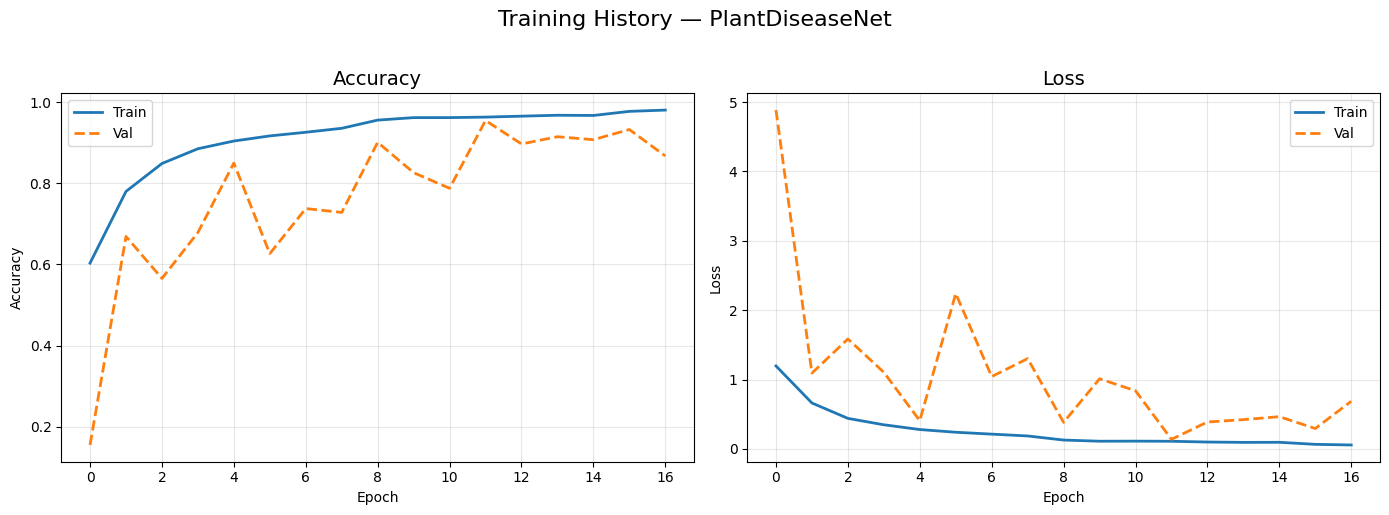

Saved: training_curves.png


In [ ]:
def plot_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy
    axes[0].plot(history.history['accuracy'],     label='Train', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Val',   linewidth=2, linestyle='--')
    axes[0].set_title('Accuracy', fontsize=14)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Loss
    axes[1].plot(history.history['loss'],     label='Train', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Val',   linewidth=2, linestyle='--')
    axes[1].set_title('Loss', fontsize=14)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle('Training History — PlantDiseaseNet', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: training_curves.png")

plot_history(history)

In [ ]:
model = tf.keras.models.load_model('best_plant_model.keras')

# Evaluate on validation set
val_loss, val_acc = model.evaluate(val_gen, verbose=1)
print(f"\nValidation Loss    : {val_loss:.4f}")
print(f"Validation Accuracy: {val_acc*100:.2f}%")

194/194 ━━━━━━━━━━━━━━━━━━━━ 12s 48ms/step - accuracy: 0.9547 - loss: 0.1393

Validation Loss    : 0.1393
Validation Accuracy: 95.47%


In [ ]:
# Full classification report
val_gen.reset()
y_pred_probs = model.predict(val_gen, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_gen.classes

short_names = [name.split('___')[-1][:25] for name in class_names]

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=short_names))

194/194 ━━━━━━━━━━━━━━━━━━━━ 12s 49ms/step

Classification Report:
                           precision    recall  f1-score   support

           Bacterial_spot       0.99      0.93      0.96       299
                  healthy       0.98      0.96      0.97       443
             Early_blight       0.97      1.00      0.99       300
              Late_blight       0.91      1.00      0.95       300
                  healthy       0.73      1.00      0.84        45
    Tomato_Bacterial_spot       0.95      0.99      0.97       638
      Tomato_Early_blight       0.96      0.94      0.95       300
       Tomato_Late_blight       0.98      0.91      0.95       572
         Tomato_Leaf_Mold       1.00      0.90      0.95       285
Tomato_Septoria_leaf_spot       0.92      0.96      0.94       531
Tomato_Spider_mites_Two_s       0.96      0.89      0.92       502
      Tomato__Target_Spot       0.94      0.91      0.93       421
Tomato__Tomato_YellowLeaf       1.00      0.97      0.98     

Using layer for Grad-CAM: conv2d_13


/tmp/ipykernel_1880/2165222797.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('jet')


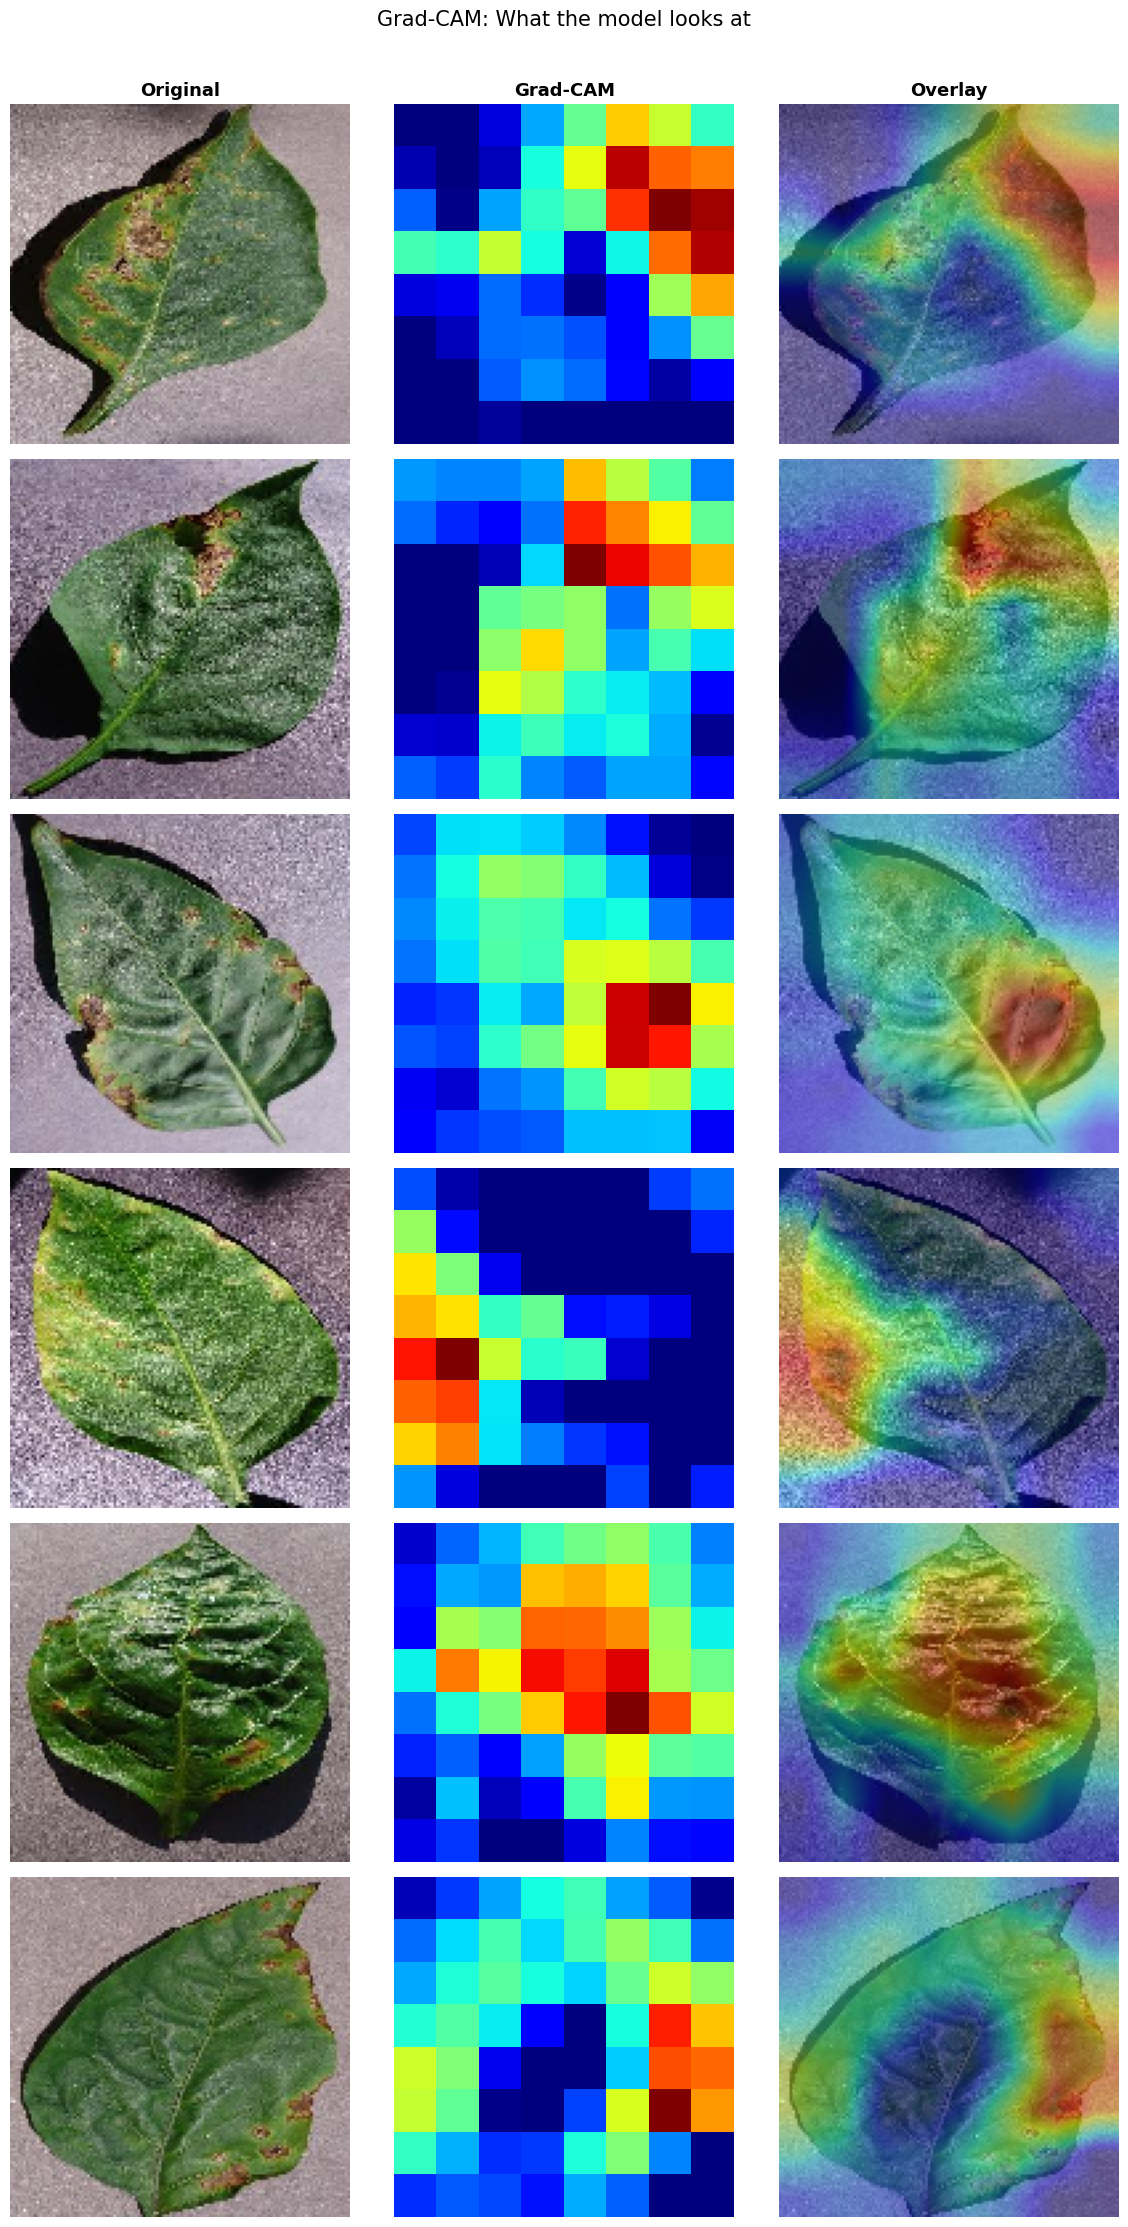

Saved: gradcam_results.png


In [ ]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    # model which outputs the last conv layer + final predictions
    grad_model = Model(
        inputs=model.input,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), int(pred_index)


def overlay_gradcam(img, heatmap, alpha=0.4):
    """Overlay the heatmap on the original image."""
    heatmap_resized = np.array(
        tf.image.resize(heatmap[..., np.newaxis], (img.shape[0], img.shape[1]))
    ).squeeze()
    colormap = cm.get_cmap('jet')
    heatmap_colored = colormap(heatmap_resized)[:, :, :3]
    return (1 - alpha) * img + alpha * heatmap_colored

# Find the name of the last depthwise or conv layer
last_conv_name = None
for layer in reversed(model.layers):
    if isinstance(layer, (Conv2D, DepthwiseConv2D)):
        last_conv_name = layer.name
        break
print(f"Using layer for Grad-CAM: {last_conv_name}")

# Visualize Grad-CAM
val_gen.reset()
images_batch, labels_batch = next(val_gen)

fig, axes = plt.subplots(6, 3, figsize=(12, 22))
col_titles = ['Original', 'Grad-CAM', 'Overlay']
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=13, fontweight='bold')

for i in range(6):
    img = images_batch[i]
    img_input = np.expand_dims(img, 0)

    heatmap, pred_idx = make_gradcam_heatmap(img_input, model, last_conv_name)
    true_idx = int(np.argmax(labels_batch[i]))
    overlay = overlay_gradcam(img, heatmap)

    true_label = short_names[true_idx]
    pred_label = short_names[pred_idx]
    color = 'green' if true_idx == pred_idx else 'red'

    axes[i, 0].imshow(img)
    axes[i, 0].set_ylabel(f"True: {true_label}", fontsize=8, color='black')
    axes[i, 0].set_xlabel(f"Pred: {pred_label}", fontsize=8, color=color)

    axes[i, 1].imshow(heatmap, cmap='jet')
    axes[i, 1].set_xlabel('Activation heatmap', fontsize=8)

    axes[i, 2].imshow(np.clip(overlay, 0, 1))
    axes[i, 2].set_xlabel('Overlay', fontsize=8)

    for col in range(3):
        axes[i, col].axis('off')

plt.suptitle('Grad-CAM: What the model looks at', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('gradcam_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: gradcam_results.png")


  Standard CNN parameters :    2,313,935
  PlantDiseaseNet params  :      281,295
  Reduction               : 8.2x fewer parameters


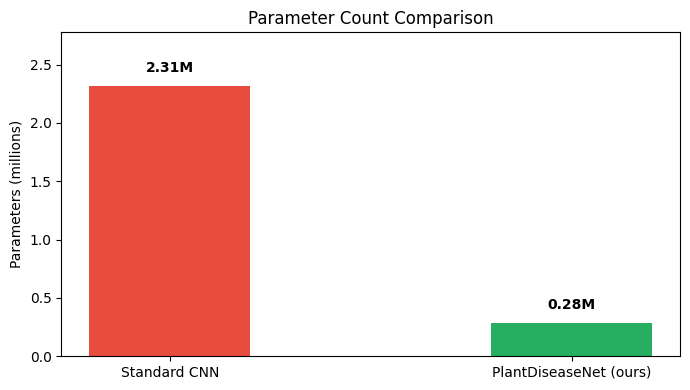

Saved: param_comparison.png


In [ ]:
# standard CNN  for comparison
def build_standard_cnn(num_classes, img_size=128):
    inputs = Input(shape=(img_size, img_size, 3))
    x = Conv2D(32, 3, strides=2, padding='same', activation='relu')(inputs)
    x = Conv2D(64, 3, padding='same', activation='relu')(x)
    x = MaxPooling2D()(x)
    x = Conv2D(128, 3, padding='same', activation='relu')(x)
    x = Conv2D(128, 3, padding='same', activation='relu')(x)
    x = MaxPooling2D()(x)
    x = Conv2D(256, 3, padding='same', activation='relu')(x)
    x = Conv2D(256, 3, padding='same', activation='relu')(x)
    x = MaxPooling2D()(x)
    x = Conv2D(512, 3, padding='same', activation='relu')(x)
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.4)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    return Model(inputs, outputs, name='StandardCNN')

standard_model = build_standard_cnn(NUM_CLASSES, IMG_SIZE)

our_params      = model.count_params()
standard_params = standard_model.count_params()

print("\n" + "="*50)
print(f"  Standard CNN parameters : {standard_params:>12,}")
print(f"  PlantDiseaseNet params  : {our_params:>12,}")
print(f"  Reduction               : {standard_params/our_params:.1f}x fewer parameters")
print("="*50)

# Bar chart comparison
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    ['Standard CNN', 'PlantDiseaseNet (ours)'],
    [standard_params / 1e6, our_params / 1e6],
    color=['#e74c3c', '#27ae60'],
    width=0.4
)
ax.set_ylabel('Parameters (millions)')
ax.set_title('Parameter Count Comparison')
for bar, val in zip(bars, [standard_params, our_params]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val/1e6:.2f}M', ha='center', va='bottom', fontweight='bold')
ax.set_ylim(0, max(standard_params, our_params)/1e6 * 1.2)
plt.tight_layout()
plt.savefig('param_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: param_comparison.png")

In [ ]:
# Save final model
model.save('plant_disease_final_model.keras')
print("Model saved!")

# Download all outputs
from google.colab import files

for fname in [
    'plant_disease_final_model.keras',
    'training_curves.png',
    'confusion_matrix.png',
    'gradcam_results.png',
    'param_comparison.png'
]:
    if os.path.exists(fname):
        files.download(fname)
        print(f"Downloaded: {fname}")

Model saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: plant_disease_final_model.keras


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: gradcam_results.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: param_comparison.png
